# Machine Learning Research on the Stellar Classification Dataset (SDSS17)

## Note for the reviewer

For the previous project [mahalanobis-prototype-classifier](https://github.com/DimovDimo/mahalanobis-prototype-classifier) I got the following rating:

`"В проекта има полезни части: SDSS класификацията, custom / transparent моделите и идеята, че когато физичен закон е известен, ML не трябва да се преструва, че го е преоткрил. Проблемът е, че добрата работа се губи под много тежък и преувеличен език. Бих пренаписал голяма част от текста и бих фокусирал проекта върху може би една идея: например кога класическият физически модел е по-добър, кога ML добавя стойност и как я проверяваме. Иначе много ме кефи форматирането. Бележка: Искаше ми се да останеш с SDSS dataset-a и да нямаш halting problem така от нищото :D."`

Here's how the **previous project was developed**, which may not have been clear due to the `"много тежък и преувеличен език"`:
1. I created mahalanobis for clustering and saw that it does well with simulated data, but with real data, ordinary ML algorithms did better.
2. I showed where ML algorithms have limitations.
3. Since the halting problem has been an intractable constraint since before the advent of machine learning algorithms, I have separated it into another notebook.
4. I conducted an ML study on SDSS17 by comparing several algorithms.
5. I conducted an ML study on the CERN data, but I used non-standard approaches that are rarely used in ML research.

In general, the **previous project was**:
1. My algorithm does not perform better than ready-made ones.
2. I show what limitations ML algorithms have.
3. I conducted an ML study with standard and non-standard methods.

The project had `"много тежък и преувеличен език"` because I tried to make it **sound academic and scientifically accurate**. And this is the same language that **I observed in scientific papers about ML**, that is, it seemed to be written correctly. Considering that I tried to present things as other ML research, I think the Mahalanobis project turned out well, but just with too much explaining and some things that are related to the project but do not seem to be directly related (and this probably created confusion).

## Current project

I will **base this project on the recommendations** from the previous one's evaluation:
1. `"фокусирал проекта върху може би една идея: например кога класическият физически модел е по-добър, кога ML добавя стойност и как я проверяваме"`.
2. `"Искаше ми се да останеш с SDSS dataset-a и да нямаш halting problem така от нищото"`.

Here's how I will do this project:
1. I will focus only on one dataset **SDSS17**. `"да останеш с SDSS dataset"`
2. Without any simulated data.
3. Without any additional algorithmic and problem presentations. `"да нямаш halting problem"`
4. I will use **the proposed idea**. `"една идея: например кога класическият физически модел е по-добър, кога ML добавя стойност и как я проверяваме"`
5. First I start with the standard data loading, and data cleaning, and EDA.
6. Then I will build up with physical and ML models.
7. I will try to think of ways (at least one way) how to check whether the physical or ML model is better.
8. I will try to present mathematically the physical and ML models. `"идеята, че когато физичен закон е известен, ML не трябва да се преструва, че го е преоткрил"`
9. I will use only one `SDSS17-ML-Research.ipynb` so as **not to distract the reader with multiple parts**.

Okay, let's get started.

## Main Challenge

I remember reading a critique of an ML model that managed to predict the orbits of planets. Although I can't find that critique to quote it now, the literal critique was `I don't want predictions, I want understanding.`. This means that the model makes predictions but doesn't derive the physical laws for the orbits. Of course, there is ML like `symbolic regression` that derives formulas, but there is no guarantee that they are physical laws.

So the **main challenge** is `ML models cannot derive any physical laws, only make predictions.`

The **second most important challenge** is `Physical laws are accurate and verified many times, while ML models give a large deviation in accuracy and are difficult to verify (some are black boxes or very complex)`.

## How to overcome them

We will **not compete with physical laws**, but as was shown in the idea of the project we will try to find when ML models lag behind and when they help predictions. So to have the most accurate predictions, they will probably (but I am not sure) depending on the problem will be a combination of physical laws and ML.

## Second note for the reviewer

Since this is ML research I will try to stick to it as academically and scientifically as possible. There is a danger for the reader that this will sound like very heavy and exaggerated language, but I try to write things with the exact terminology. For some things there are no exact terms and it is still important to give a clear explanation (this may sound like a bit of a long explanation sometimes). In general, I will try to make things understandable (as much as they are understandable in the scientific articles I have read) and yet it will probably sound too academic and maybe it may even confuse some of the readers.

One more thing, these pre-project notes and explanations turned out well. But look at even these notes, they seem to have developed a bit long as a text. Still, it was important to clarify things before starting the project.

We continue with the dry academic and scientific language, which can sometimes sound heavy and probably exaggerate, but is maximally (or at least I assume it is) accurate and detailed.

**Motivations before continuing**: Stars, Galaxies and Quasars unite (in the Stellar Classification Dataset SDSS17). Together we are stronger (against ML algorithms). Nothing can divide us (except well-known physical laws).

I hope readers find the research **interesting and educational**.

# Stellar Classification Project (SDSS17)

## 1. Project Context
In astronomy, stellar classification is the classification of stars based on their spectral characteristics. The classification scheme of galaxies, quasars, and stars is one of the most fundamental in astronomy. 

The early cataloguing of stars and their distribution in the sky has led to the understanding that they make up our own galaxy and, following the distinction that Andromeda was a separate galaxy to our own, numerous galaxies began to be surveyed as more powerful telescopes were built. This dataset aims to classify stars, galaxies, and quasars based on their spectral characteristics.

## 2. Dataset Content & Domain Knowledge
The data consists of **100,000 observations of space** taken by the SDSS (Sloan Digital Sky Survey) Data Release 17 (DR17). Every observation is described by **17 feature columns** and **1 target class column** which identifies the astronomical object.

### Target Variable (What we want to predict)
* **class:** Object class. It indicates whether the observed space entity is a:
  * `GALAXY` - A massive system of stars, stellar remnants, gas, and dark matter.
  * `STAR` - A luminous sphere of plasma held together by its own gravity.
  * `QUASAR` (QSO) - An extremely luminous active galactic nucleus powered by a supermassive black hole.

### Photometric & Positional Features (Physical Data)
* **alpha:** Right Ascension angle (at J2000 epoch). Measures the east-west celestial longitude.
* **delta:** Declination angle (at J2000 epoch). Measures the north-south celestial latitude.
* **u:** Ultraviolet filter value in the photometric system.
* **g:** Green filter value in the photometric system.
* **r:** Red filter value in the photometric system.
* **i:** Near Infrared filter value in the photometric system.
* **z:** Infrared filter value in the photometric system.
* **redshift:** Redshift value based on the increase in wavelength. Crucial for measuring cosmic distance and speed.

### Metadata & Survey Identifiers (Instrument/Operational Data)
These columns are assigned by the data processing pipeline and do not represent physical properties of the objects:
* **obj_ID:** Object Identifier, the unique value that identifies the object in the image catalog used by the CAS.
* **run_ID:** Run Number used to identify the specific scan.
* **rereun_ID:** Rerun Number to specify how the image was processed.
* **cam_col:** Camera column to identify the scanline within the run.
* **field_ID:** Field number to identify each field.
* **spec_obj_ID:** Unique ID used for optical spectroscopic objects (2 observations with the same `spec_obj_ID` share the output class).
* **plate:** Plate ID, identifies each physical plate in SDSS spectrograph.
* **MJD:** Modified Julian Date, used to indicate when a given piece of SDSS data was taken.
* **fiber_ID:** Fiber ID that identifies the optical fiber that pointed the light at the focal plane in each observation.


# Data Acquisition and Loading

We utilize the `kagglehub` library to download the SDSS17 Stellar Classification dataset from Kaggle. Once stored in the local cache environment, we identify the dataset's path and load the primary CSV file into a Pandas DataFrame.


In [6]:
import os
import pandas as pd
import kagglehub

# Download the latest version of the SDSS17 dataset silently
path = kagglehub.dataset_download("fedesoriano/stellar-classification-dataset-sdss17")

# Automatically locate the CSV file within the downloaded path
all_files = os.listdir(path)
csv_files = [file for file in all_files if file.endswith('.csv')]

if len(csv_files) > 0:
    # Take the first available CSV file from the list to avoid TypeError
    target_csv = csv_files[0]
    full_path = os.path.join(path, target_csv)
    
    # Read the CSV file into a DataFrame
    df = pd.read_csv(full_path)
    print(f"Successfully loaded file: {target_csv}")
    print(f"Data shape: {df.shape} rows and {df.shape} columns.")
else:
    print("Error: No CSV file discovered in the downloaded folder.")


Successfully loaded file: star_classification.csv
Data shape: (100000, 18) rows and (100000, 18) columns.


# Initial Data Inspection

We inspect the first few rows of the loaded DataFrame to understand the structure, format, and values of each feature in the dataset.


In [7]:
# Display the first 5 rows of the dataset
df.head()


,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


# Feature Selection

To prevent our machine learning models from overfitting and to reduce training complexity, we remove operational metadata columns. 

* **Columns to Drop:** `obj_ID`, `run_ID`, `rerun_ID`, `cam_col`, `field_ID`, `spec_obj_ID`, `plate`, `MJD`, `fiber_ID`. These variables are unique telescope identifiers, software configuration logs, or execution dates. They contain no physical or spectral characteristics of the observed celestial bodies.
* **Columns to Retain:** Spatial orientation parameters (`alpha`, `delta`), photometric filter outputs (`u`, `g`, `r`, `i`, `z`), the critical distance metric (`redshift`), and the target variable (`class`).


In [8]:
# Define the list of metadata columns that are not useful for classification
columns_to_drop = [
    'obj_ID', 'run_ID', 'rerun_ID', 'cam_col', 
    'field_ID', 'spec_obj_ID', 'plate', 'MJD', 'fiber_ID'
]

# Drop the columns from the DataFrame
df_cleaned = df.drop(columns=columns_to_drop, errors='ignore')

# Verify the changes by printing the new dimensions and remaining columns
print(f"Original shape: {df.shape}")
print(f"Cleaned dataset shape: {df_cleaned.shape}")
print("\nRemaining columns for machine learning:")
print(list(df_cleaned.columns))


Original shape: (100000, 18)
Cleaned dataset shape: (100000, 9)

Remaining columns for machine learning:
['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'class', 'redshift']


# Feature Engineering: Color Indexes

In astrophysics, the absolute magnitudes of photometric filters can vary with object brightness. However, the differences between consecutive filters known as **Color Indexes** (e.g., $u - g$, $g - r$) capture the shape and slope of the spectrum. 

We engineer these new features to help the machine learning models better differentiate between galaxies, stars, and quasars. After creating the new features, we inspect the updated dataset.


In [9]:
# Create new astronomical features based on color differences
df_cleaned['u_g'] = df_cleaned['u'] - df_cleaned['g']
# Green minus Red filter
df_cleaned['g_r'] = df_cleaned['g'] - df_cleaned['r']
# Red minus Near-Infrared filter
df_cleaned['r_i'] = df_cleaned['r'] - df_cleaned['i']
# Near-Infrared minus Infrared filter
df_cleaned['i_z'] = df_cleaned['i'] - df_cleaned['z']

# Display the configuration and new dimensions
print(f"Shape after feature engineering: {df_cleaned.shape}")

# View the head of the updated dataset to see the new columns
df_cleaned.head()


Shape after feature engineering: (100000, 13)


,alpha,delta,u,g,r,i,z,class,redshift,u_g,g_r,r_i,i_z
0,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,GALAXY,0.634794,1.60352,1.88029,1.22928,0.37202
1,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,GALAXY,0.779136,1.94571,0.24744,1.41632,-0.44615
2,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,GALAXY,0.644195,2.59918,2.05413,1.26119,0.40030
3,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,GALAXY,0.932346,-1.63974,2.16494,1.10708,1.25444
4,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,GALAXY,0.116123,1.85690,1.08281,0.52036,0.43250


# Advanced Feature Engineering

To provide deeper representation for our classification algorithms, we engineer additional domain-specific astronomical features:

* **total_flux_proxy:** The sum of all magnitude filters ($u + g + r + i + z$), serving as a proxy for the total apparent brightness across the observed spectrum.
* **u_z_ratio:** The ratio of Ultraviolet to Infrared ($u / z$), which captures the extreme balance between the shortest and longest wavelengths.
* **spectral_std:** The standard deviation across the five filters for each observation, describing how volatile or flat the object's spectral curve is.


In [10]:
# List of the primary photometric filters
filters = ['u', 'g', 'r', 'i', 'z']

# 1. Total brightness proxy
df_cleaned['total_flux_proxy'] = df_cleaned[filters].sum(axis=1)

# 2. Extreme wavelength ratio (UV vs Infrared)
# Adding a small epsilon (1e-6) to prevent division by zero in case of anomalies
df_cleaned['u_z_ratio'] = df_cleaned['u'] / (df_cleaned['z'] + 1e-6)

# 3. Standard deviation across the spectral profile
df_cleaned['spectral_std'] = df_cleaned[filters].std(axis=1)

# Verify the final engineered features dataset shape and attributes
print(f"Dataset shape after advanced feature engineering: {df_cleaned.shape}")
print("\nUpdated list of columns:")
print(list(df_cleaned.columns))

# Display the first 3 rows to inspect the new columns
df_cleaned.head(3)


Dataset shape after advanced feature engineering: (100000, 16)

Updated list of columns:
['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'class', 'redshift', 'u_g', 'g_r', 'r_i', 'i_z', 'total_flux_proxy', 'u_z_ratio', 'spectral_std']


,alpha,delta,u,g,r,i,z,class,redshift,u_g,g_r,r_i,i_z,total_flux_proxy,u_z_ratio,spectral_std
0,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,GALAXY,0.634794,1.60352,1.88029,1.22928,0.37202,104.50857,1.270575,2.148486
1,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,GALAXY,0.779136,1.94571,0.24744,1.41632,-0.44615,112.97630,1.146353,1.398011
2,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,GALAXY,0.644195,2.59918,2.05413,1.26119,0.40030,106.83356,1.333265,2.615292


# Outlier Detection and Removal using the IQR Method

To eliminate instrumentation errors (such as the known SDSS -9999 magnitude drops) and extreme anomalies, we apply the Interquartile Range (IQR) method. 

We scan all numeric features, define safe operational boundaries (1.5 times the IQR), and discard rows that fall outside these limits to ensure clean, reliable distributions for our machine learning models.


In [11]:
# Identify all numerical columns for outlier filtration (excluding the 'class' column)
numerical_features = df_cleaned.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Create a fresh copy to prevent SettingWithCopyWarning
df_no_outliers = df_cleaned.copy()

# Apply the IQR technique systematically
for col in numerical_features:
    Q1 = df_no_outliers[col].quantile(0.25)
    Q3 = df_no_outliers[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # Establish upper and lower bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Keep only the rows within the valid mathematical boundaries
    df_no_outliers = df_no_outliers[(df_no_outliers[col] >= lower_bound) & (df_no_outliers[col] <= upper_bound)]

# Output verification summary
initial_shape = df_cleaned.shape
final_shape = df_no_outliers.shape
rows_removed = initial_shape[0] - final_shape[0]

print(f"Original Row Count: {initial_shape[0]}")
print(f"Cleaned Row Count (Post-IQR): {final_shape[0]}")
print(f"Total Outlier Rows Eliminated: {rows_removed} ({rows_removed / initial_shape[0] * 100:.2f}%)")


Original Row Count: 100000
Cleaned Row Count (Post-IQR): 82330
Total Outlier Rows Eliminated: 17670 (17.67%)


# Exploratory Data Analysis (EDA): Visualizing Cleaned Stellar Data

With the extreme outliers removed, we perform Exploratory Data Analysis (EDA). This stage allows us to inspect target class balance, look for physical separability in our features, and review linear correlations across the engineered feature space.


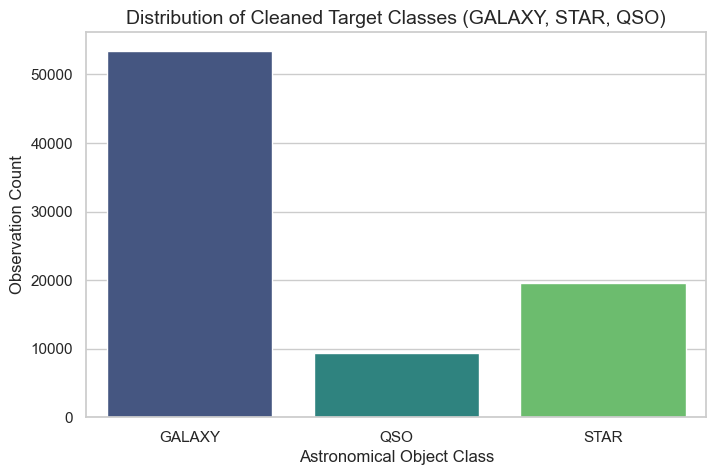

--- Class Value Counts (Post-IQR) ---
class
GALAXY    53493
STAR      19538
QSO        9299
Name: count, dtype: int64

--- Percentage Distribution ---
class
GALAXY    64.973886
STAR      23.731325
QSO       11.294789
Name: proportion, dtype: float64


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set global plotting style and layout configuration
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)

# 1. Target Class Distribution Analysis
plt.figure(figsize=(8, 5))
# Added hue and legend=False to fix the deprecation warning
sns.countplot(data=df_no_outliers, x='class', hue='class', palette='viridis', legend=False)
plt.title("Distribution of Cleaned Target Classes (GALAXY, STAR, QSO)", fontsize=14)
plt.xlabel("Astronomical Object Class", fontsize=12)
plt.ylabel("Observation Count", fontsize=12)
plt.show()

# Print out exact class counts for audit
print("--- Class Value Counts (Post-IQR) ---")
print(df_no_outliers['class'].value_counts())
print("\n--- Percentage Distribution ---")
print(df_no_outliers['class'].value_counts(normalize=True) * 100)


### Redshift and Color Index Feature Separability

We investigate how the clean `redshift` values and our engineered color differences (like $g - r$) vary across the three space object categories. These physics-based distributions serve as powerful discriminators for classification.
